# Stellar companion

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from exogaia.data import EpochAstrometry
from exogaia.leastsq import LeastSquares

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [3]:
np.random.seed(42)

In [4]:
source_id = 6199395656645840384  # HD 135344 A
primary_mass = (2.2, 0.1)  # (Msun)
mass_2 = 0.7  # (Msun)

In [5]:
epoch_astrom = EpochAstrometry(primary_mass=primary_mass, gaia_release='DR4')


----------------
Epoch astrometry
----------------

Gaia release: DR4
Reference epoch: 2017.5

Primary mass (Msun): 2.20 +/- 0.10


In [6]:
star_param = epoch_astrom.query_source(source_id=source_id, gaia_release='DR3')


---------------
Querying source
---------------

Gaia release: DR3
Source ID: 6199395656645840384

INFO: Query finished. [astroquery.utils.tap.core]

RA = 228.954 deg +/- 0.038 mas
Dec = -37.149 deg +/- 0.026 mas
Parallax = 7.411 +/- 0.040 mas
Proper motion in RA = -18.738 +/- 0.051 mas/yr
Proper motion in Dec = -24.008 +/- 0.035 mas/yr
G-band magnitude = 7.748
Pseudocolor = 1.73 um-1

UWE = 1.96
RUWE = 0.95
Astrometric excess noise (mas) = 0.2075 +/- 0.0103
Non single star = 0


In [7]:
model_param = {
    'ecc': 0.0,
    'tau': 0.5,
    'inc': np.radians(30.),
    'aop': np.radians(0.),
    'pan': np.radians(90.),
    'sma': 2.,
}

In [8]:
model_param = epoch_astrom.simulate_data(
    model_param=model_param,
    mass_2=mass_2,
    flux_ratio=None,
    occ_rate=None,
    sigma_per_ccd=None,
    csv_out=None,
)


-------------
Simulate data
-------------

System type: binary

Primary mass (Msun): 2.20 +/- 0.10

AL scan uncertainty (per CCD) = 193.14 uas
AL scan uncertainty (per transit) = 68.29 uas

Additional parameters:
   - Primary mass (Msun) = 2.20
   - Companion mass (Msun) = 7.00e-01
   - Mass ratio = 3.18e-01
   - Flux ratio = 1.82e-02
   - Relative semi-major axis (au) = 2.00

-----------------------
Calculate stellar track
-----------------------

Stellar parameters:
   - RA offset (mas) = 0.000
   - Dec offset (mas) = 0.000
   - Parallax (mas) = 7.411
   - Proper motion in RA (mas/yr) = -18.738
   - Proper motion in Dec (mas/yr) = -24.008

---------------------
Calculate orbit model
---------------------

Orbit parameters:
   - Period (days) = 606.647
   - Eccentricity = 0.000
   - Relative time of periastron = 0.500
   - Semi-major axis (mas) = 14.821
   - Inclination (deg) = 30.000
   - Argument of periastron (deg) = 0.000
   - PA of ascending node (deg) = 90.000

Applying AL bias

In [9]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)


--------------------------
Orbit grid (12-parameters)
--------------------------



  0%|          | 0/900 [00:00<?, ?it/s]


Best-fit RUWE = 15.831

Best-fit stellar track:
   - RA offset (mas) = 3.682 +/- 0.141
   - Dec offset (mas) = -1.615 +/- 0.114
   - Parallax (mas) = 8.262 +/- 0.072
   - mu in RA (mas/yr) = -18.873 +/- 0.039
   - mu in Dec (mas/yr) = -23.737 +/- 0.020

Best-fit orbit:
   - Period (days) = 672.336
   - Eccentricity = 0.800
   - Relative time of periastron = 0.07
   - Thiele-Innes A = -1.058 +/- 0.079
   - Thiele-Innes B = 3.214 +/- 0.110
   - Thiele-Innes F = -2.950 +/- 0.086
   - Thiele-Innes G = -1.770 +/- 0.132

Derived parameters:
   - Semi-major axis of photocenter (mas) = 3.771 +/- 0.110
   - Relative semi-major axis (au) = 2.118
   - Mass function (Msun) = 2.806e-02
   - Companion mass (Msun) = 6.043e-01

Conversion to campbell elements:
   - Period = 672.336 days
   - Eccentricity = 0.800
   - Relative time of periastron = 0.067
   - Semi-major axis of photocenter (mas) = 3.771
   - Inclination (deg) = 37.004
   - Argument of periastron (deg) = 47.150
   - PA of ascending node

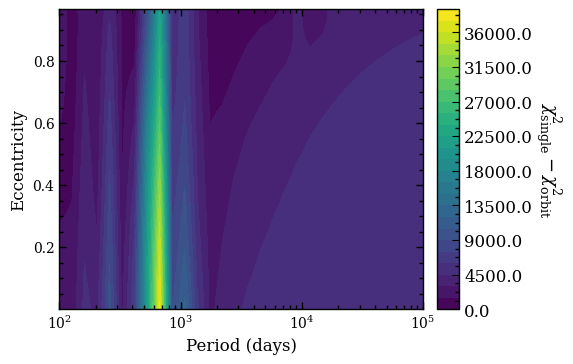

In [10]:
fig = leastsq.orbit_grid(n_points=30, map_type="chi2_det", plot_file='orbit_grid.png')


-------------------------
Orbit fit (12 parameters)
-------------------------

Reduced chi^2: 0.421
RUWE: 0.649

Best-fit stellar track:
   - RA offset (mas) = -0.025 +/- 0.044
   - Dec offset (mas) = -0.043 +/- 0.038
   - Parallax (mas) = 7.428 +/- 0.017
   - mu in RA (mas/yr) = -18.740 +/- 0.010
   - mu in Dec (mas/yr) = -24.011 +/- 0.006

Best-fit orbit:
   - Period (days) = 606.800 +/- 0.357
   - Eccentricity = 0.011 +/- 0.008
   - Relative time of periastron = 0.243 +/- 0.122
   - Semi-major axis of photocenter (mas) = 3.289 +/- 0.021
   - Inclination (deg) = 28.290 +/- 0.884
   - Argument of periastron (deg) = 85.154 +/- 43.771
   - PA of ascending node (deg) = 92.366 +/- 1.934

Number of function evaluations: 21
Number of Jacobian evaluations: 21

Derived parameters:
   - Relative semi-major axis (au) = 1.985
   - Mass function (Msun) = 3.145e-02
   - Companion mass (Msun) = 6.318e-01


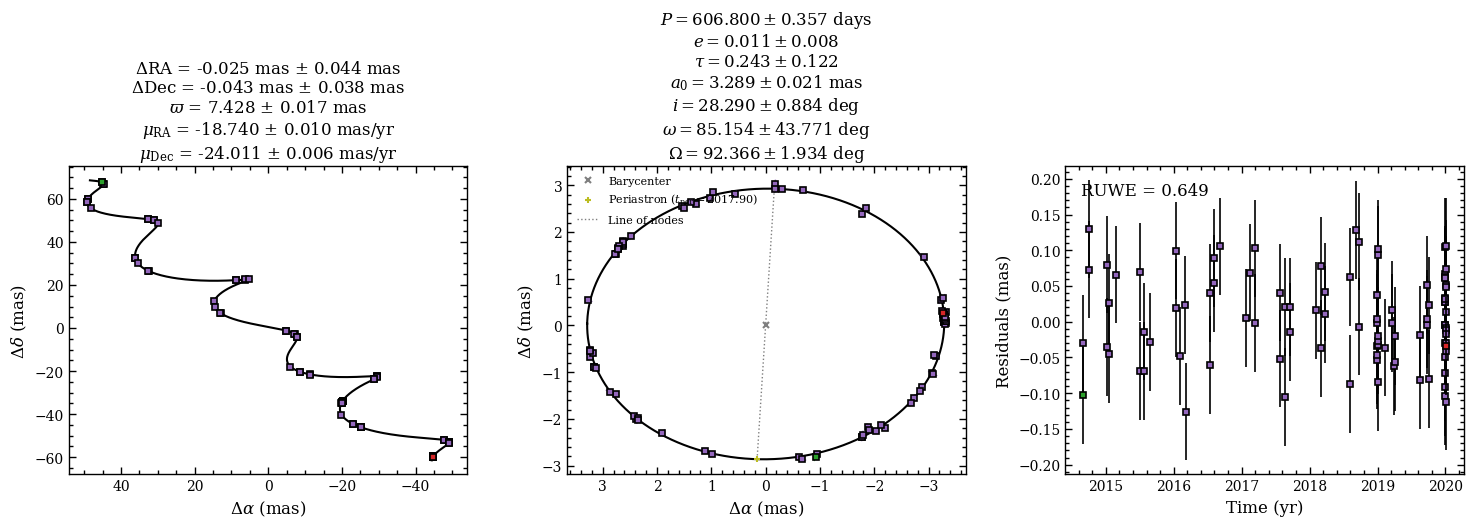

In [11]:
fig = leastsq.orbit_fit(inc_jitter=False, plot_file='orbit_fit.png')